Calculate magnetic field strength $B$ at the pole $\theta =0$, in terms of the gradients of $\psi$ 
$$
B = \frac{1}{r\sin\theta}|\nabla\psi|
$$

The gradient $\nabla\psi$ is
$$|\nabla \psi| = \sqrt{\left(\frac{\partial\psi}{\partial r}\right)^2 + \frac{1}{r^2}\left(\frac{\partial\psi}{\partial \theta}\right)^2}$$
We choose a flux function
$$\psi = \frac{\psi_*R_*\sin^2\theta}{r}$$
So the partial derivatives are
$$
\begin{align}
\frac{\partial \psi}{\partial r} = -\frac{\psi_*R_*\sin^2\theta}{r^2}, \qquad\text{and}\qquad\frac{\partial\psi}{\partial\theta} = \frac{2\psi_*R*\sin\theta\cos\theta}{r}
\end{align}
$$
Combining
$$\begin{align}
|\nabla \psi| &= \sqrt{\left(\frac{\psi_*R_*\sin^2\theta}{r^2}\right)^2 + \frac{1}{r^2}\left(\frac{2\psi_*R*\sin\theta\cos\theta}{r}\right)^2}\\
&= \frac{\psi_*R_*\sin\theta}{r^2}\sqrt{\sin^2\theta + 4\cos^2\theta}\\
&= \frac{\psi_*R_*\sin\theta}{r^2}\sqrt{1 + 3\cos^2\theta}
\end{align}
$$
So the magnetic field is:
$$B = \frac{\psi_*R_*}{r^3}\sqrt{1 + 3\cos^2\theta}$$

At $\theta = 0$, this becomes:
$$B = \frac{\psi_*R_*}{r^3}$$

In grid coordinates $r = x_0(x+a), \,\mu = \cos\theta$:

$$B = \frac{\psi_0}{x_0^2}\frac{\psi_*}{\psi_0}\frac{a}{(x+a)^3}$$

We want to compare the accuracy of the original method for calculating the adjustment to $dM/d\psi$ with that of a second order scheme using `numpy.gradient`. To do this, we construct $dM/d\psi$, integrate to get $M(\psi)$, add a prescribed adjustment mass $M_{\rm adj}(\psi)$, and differentiate using `np.gradient` to recover $dM/d\psi$. We compare this to the original method of calculating $\Delta M / \Delta \psi$, and then adding to $dM/d\psi$ directly.

So the three methods are:
1. Start with $dM/d\psi$, integrate to get $M(\psi)$, modify by $M_a$, then differentiate result with `np.gradient`;
2. Add $\Delta M_a/\Delta \psi$ to $dM/d\psi$ directly ("rough 1");
3. Differentiate $M_a$ with `np.gradient` and add to $dM/d\psi$ ("rough 2")

In [92]:
import sys
# decorator to allow interactive plots in jupyterlab
%matplotlib ipympl 
import numpy as np
from matplotlib import pyplot as plt

In [191]:
# Setup, create PM04 dmdpsi profile
B_star = 1e8
R_star = 1e4
psi_star = 0.5*B_star*R_star**2
cs = 1e6
M_sol = 1.989e30
M_star = 1.4*M_sol
G = 6.6726e-11
x0 = cs**2*R_star**2/(G*M_star)
ma_frac = 5.e-7
ma = ma_frac*M_sol
psi_0 = np.sqrt(cs*cs*ma/x0/x0/x0)
n_contours = 127
dmu = 1./n_contours
mu_levels = np.empty(n_contours)
bratio = 10

for i in range(n_contours):
    contour_mesh_value = (n_contours - i)/(n_contours+1.)/dmu
    mu_levels[i] = contour_mesh_value*dmu

psi_levels = (psi_star/psi_0)*(1-mu_levels*mu_levels)

pm04_dmdpsi = 0.5*psi_0/psi_star*bratio*np.exp(-psi_levels*psi_0/psi_star*bratio)/(1.-np.exp(-bratio))

# add psi = 0 and psi = psi_star to levels
psi_levels_append = np.append(np.append(0,psi_levels), psi_star/psi_0)
pm04_dmdpsi_append = 0.5*psi_0/psi_star*bratio*np.exp(-psi_levels_append*psi_0/psi_star*bratio)/(1.-np.exp(-bratio))

PM04 mass = 0.50000209400761
PM04 mass(psi=psi_star) = 0.5000020801477927
Net added: -1.7347162590444127e-16


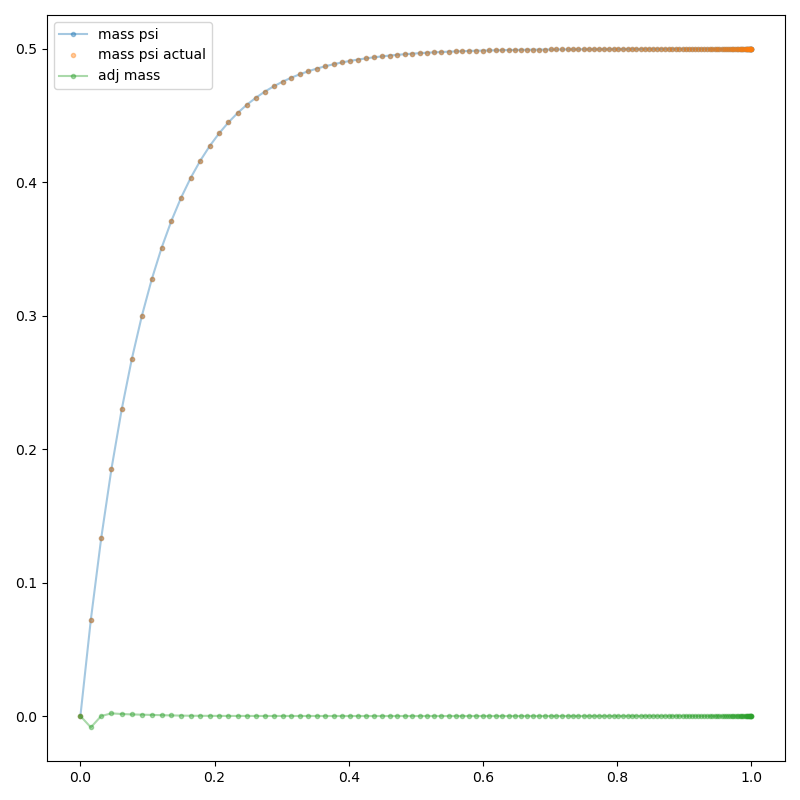

In [225]:
# integrate PM04 profile to get M(psi), create adjusted_mass profile
from scipy import integrate
total_mass = integrate.simpson(pm04_dmdpsi_append, psi_levels_append)
mass_psi = np.zeros(len(psi_levels_append)-1)
mass_psi_actual = 0.5*(1-np.exp(-psi_levels_append[:-1]*psi_0/psi_star*bratio))/(1.-np.exp(-bratio))

for i in range(len(mass_psi)):
    mass_psi[i] = integrate.simpson(pm04_dmdpsi_append[:i+1], psi_levels_append[:i+1])

# check total mass    
print(f"PM04 mass = {total_mass}")
print(f"PM04 mass(psi=psi_star) = {mass_psi[-1]}")

# Add adjusted mass profile
adjusted_mass = np.zeros_like(mass_psi)
factor = 50
# gradient_1 = -1/factor/0.5
# gradient_2 = 1.4/factor/0.5
# adjusted_mass[:int(0.25*len(mass_psi))] = gradient_1*psi_levels[:int(0.25*len(mass_psi))]*psi_0/psi_star
# adjusted_mass[int(0.25*len(mass_psi)):int(0.5*len(mass_psi))] = gradient_1*psi_levels[int(0.25*len(mass_psi))]*psi_0/psi_star + gradient_2*(psi_levels[int(0.25*len(mass_psi)):int(0.5*len(mass_psi))] - psi_levels[int(0.25*len(mass_psi))] )*psi_0/psi_star

adjusted_mass[1] = -0.85/factor*mass_psi[-1]
adjusted_mass[2] = -0./factor*mass_psi[-1]
adjusted_mass[3] = 0.2/factor*mass_psi[-1]
adjusted_mass[4] = 0.15/factor*mass_psi[-1]
adjusted_mass[5] = 0.12/factor*mass_psi[-1]
adjusted_mass[6] = 0.10/factor*mass_psi[-1]
adjusted_mass[7] = 0.08/factor*mass_psi[-1]
adjusted_mass[8] = 0.06/factor*mass_psi[-1]
adjusted_mass[9] = 0.045/factor*mass_psi[-1]
adjusted_mass[10] = 0.03/factor*mass_psi[-1]
adjusted_mass[11] = 0.02/factor*mass_psi[-1]
adjusted_mass[12] = 0.015/factor*mass_psi[-1]
adjusted_mass[13] = 0.009/factor*mass_psi[-1]
adjusted_mass[14] = 0.007/factor*mass_psi[-1]
adjusted_mass[15] = 0.006/factor*mass_psi[-1]
adjusted_mass[16] = 0.005/factor*mass_psi[-1]
adjusted_mass[17] = 0.003/factor*mass_psi[-1]

print(f"Net added: {np.sum(adjusted_mass)*factor/mass_psi[-1]}")


# modify M(psi) to get M_adj(psi)
mass_adj = mass_psi + adjusted_mass

fig,ax = plt.subplots(figsize=(8,8))
ax.plot(psi_levels_append[:-1]*psi_0/psi_star,mass_psi, '.-', alpha=0.4, label="mass psi")
ax.plot(psi_levels_append[:-1]*psi_0/psi_star,mass_psi_actual, '.', alpha=0.4, label="mass psi actual")
# ax.plot(psi_levels_append[:-1]*psi_0/psi_star,mass_adj, '.-', alpha=0.4, label="mass psi adj")
ax.plot(psi_levels_append[:-1]*psi_0/psi_star,adjusted_mass, '.-', alpha=0.4, label="adj mass")
# ax.plot(psi_levels_append[:-1]*psi_0/psi_star,mass_adj - mass_psi, '.-', alpha=0.4, label="adj mass calc")
ax.legend()
plt.tight_layout()
plt.show()

First check: differentiate $M(\psi)$ to get $dM/d\psi$ using `np.gradient`, and compare this to the original PM04 $dM/d\psi$. Compare this calculation with two "rough" methods for calculating $dM/d\psi$ directly, by also plotting
$$
\begin{equation}
\left(\frac{dM}{d\psi}\right)_{\rm rough, 1} = \left(\frac{dM}{d\psi}\right)_{\rm PM04} + \frac{\Delta M_a}{\Delta\psi} 
\end{equation}
$$
and (using `np.gradient` on $M_a$)
$$
\begin{equation}
\left(\frac{dM}{d\psi}\right)_{\rm rough, 2} = \left(\frac{dM}{d\psi}\right)_{\rm PM04} + \frac{d}{d\psi} \left(\Delta M_a\right)
\end{equation}
$$

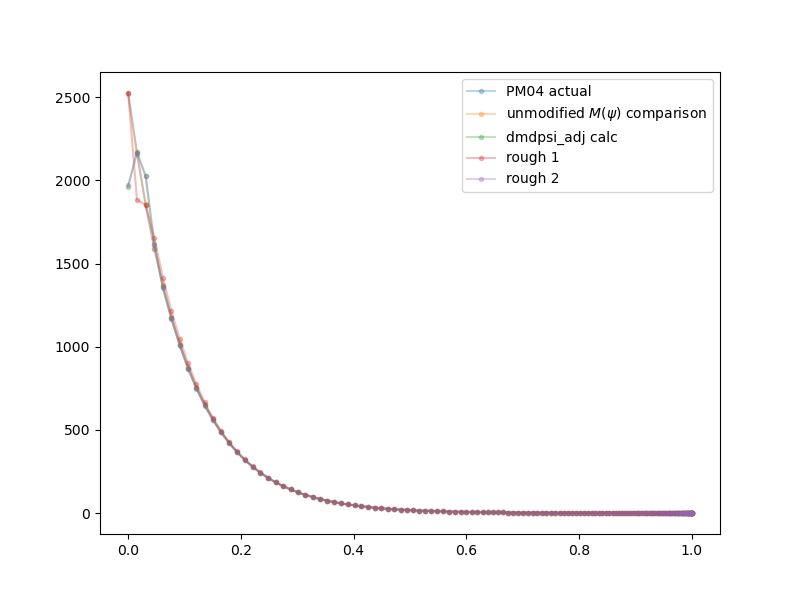

In [193]:
# differentiate integral to retrieve dmdpsi
dmdpsi_calc = np.gradient(mass_psi,psi_levels_append[:-1],edge_order=2) #original dmdpsi, unmodified. for comparison
dmdpsi_adj_calc = np.gradient(mass_adj,psi_levels_append[:-1], edge_order=2) # adjusted mass profile
d_adjustmass_dpsi = np.gradient(adjusted_mass, psi_levels_append[:-1], edge_order=2) # rough 2 method

# rough 1 way by adding Delta M/Delta psi directly
pm04_dmdpsi_calc_rough_1 = pm04_dmdpsi_append[:-1] + adjusted_mass/(psi_levels_append[1:]-psi_levels_append[:-1])
pm04_dmdpsi_calc_rough_2 = pm04_dmdpsi_append[:-1] + d_adjustmass_dpsi

# plot
fig,ax = plt.subplots(figsize=(8,6))
ax.plot(psi_levels_append*psi_0/psi_star, pm04_dmdpsi_append, '.-',alpha = 0.3,label='PM04 actual')
# ax.plot(psi_levels_append[:-1]*psi_0/psi_star, pm04_dmdpsi_calc, '.-',alpha = 0.3, label='PM04 calc')
# ax.plot(psi_levels_append[:-1]*psi_0/psi_star, np.gradient(adjusted_mass,psi_levels_append[:-1],edge_order=2), '.-',alpha = 0.3, label='grad')
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, dmdpsi_calc, '.-',alpha = 0.3, label=r'unmodified $M(\psi)$ comparison')
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, dmdpsi_adj_calc, '.-',alpha = 0.3, label='dmdpsi_adj calc')
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, pm04_dmdpsi_calc_rough_1, '.-',alpha = 0.3, label='rough 1')
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, pm04_dmdpsi_calc_rough_2, '.-',alpha = 0.3, label='rough 2')
# ax.plot(psi_levels_append[:-1]*psi_0/psi_star, dmdpsi_adj_calc-pm04_dmdpsi_calc, '.-',alpha = 0.3, label='delta dmdpsi')
# ax.plot(psi_levels_append[:-1]*psi_0/psi_star, d_adjustmass_dpsi, '.-',alpha = 0.3, label='d adj mass dpsi')
ax.legend()
plt.show()

Notice that the methods that use `np.gradient` have adjustments to $dM/d\psi$ at $\psi=0$, even though $\Delta M_a(\psi=0) = 0$. This is because they use a second order central difference method for the gradient at the endpoints, which takes values from the inner points.


So we have $dM/d\psi$ for the un-altered profile, the profile found by adding $\Delta M_a$ to $M(\psi)$, and the two "rough" ways. Now we want to again integrate these $dM/d\psi$ profiles to see how the recovered profiles match $M(\psi)$, or $M(\psi) + \Delta M_a$ in the case of the adjusted versions. 

In particular, we can see whether we can get the adjusted mass $M_{\rm adj}(\psi)$ back by integrating the difference between $dM/d\psi_{\rm adj}$ and $dM/d\psi$ (which should be equal to $\int\Delta M_a/\Delta \psi \,d\psi$). We are testing whether

$$
\begin{align}
\int \left(\frac{dM_{\rm adj}}{d\psi} \right) d\psi &\stackrel{?}{=} M(\psi) + \Delta M_a\\
&\\
\int \left(\frac{dM}{d\psi} + \frac{\Delta M_a}{\Delta\psi}\right) d\psi &\stackrel{?}{=} M(\psi) + \Delta M_a\\
&\\
\int \left(\frac{dM}{d\psi} + \frac{d}{d\psi}M_a(\psi)\right) d\psi &\stackrel{?}{=} M(\psi) + \Delta M_a
\end{align}
$$

The first case is where we have integrated $dM/d\psi$, added the adjusted mass to get $M_{\rm adj}$, then differentiated. The second case is where we have adjusted $dM/d\psi$ directly by adding $\Delta M_a/\Delta\psi$, and the third is where we have also modified $dM/d\psi$ directly, but by adding $d(M_a)/d\psi$ (i.e. after differentiating $M_a$). We compare the errors of each method by comparing it to $M_{\rm adj}(\psi)$.

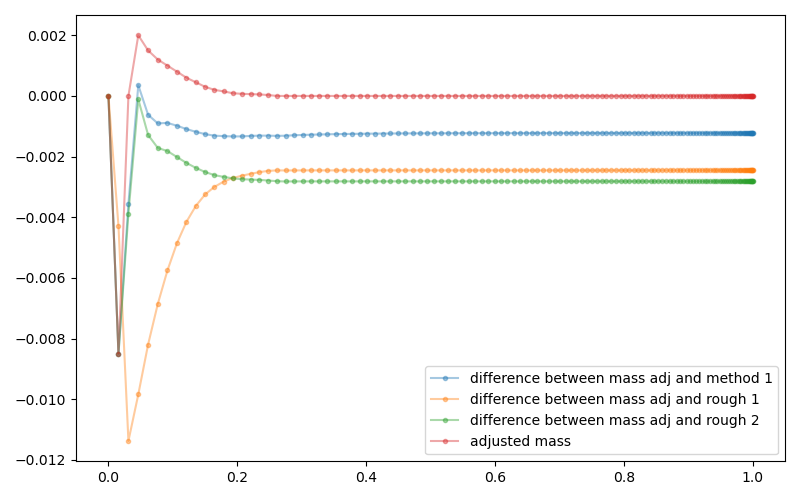

In [194]:
# integrate again to check
mass_adj_calc = [integrate.simpson(dmdpsi_adj_calc[:i+1], psi_levels_append[:i+1]) for i in range(len(mass_adj))]
mass_adj_rough_1 = [integrate.simpson(pm04_dmdpsi_calc_rough_1[:i+1], psi_levels_append[:i+1]) for i in range(len(mass_adj))]
mass_adj_rough_2 = [integrate.simpson(pm04_dmdpsi_calc_rough_2[:i+1], psi_levels_append[:i+1]) for i in range(len(mass_adj))]
# mass_adj_delta = [integrate.simpson(dmdpsi_adj_calc[:i+1] - dmdpsi_calc[:i+1], psi_levels_append[:i+1])for i in range(len(mass_adj))]

# subtract off M(psi) to (hopefully) leave Delta M_a, and compare with Delta M_a (actual)
mass_adj_delta = mass_adj_calc - mass_psi
mass_adj_delta_rough_1 = mass_adj_rough_1 - mass_psi
mass_adj_delta_rough_2 = mass_adj_rough_2 - mass_psi

# plot compare mass_adj and mass_adj_2
fig,ax = plt.subplots(figsize=(8,5))
ax.plot(psi_levels_append[:-1]*psi_0/psi_star,mass_adj_delta, '.-', alpha=0.4, label="difference between mass adj and method 1")
ax.plot(psi_levels_append[:-1]*psi_0/psi_star,mass_adj_delta_rough_1, '.-', alpha=0.4, label="difference between mass adj and rough 1")
ax.plot(psi_levels_append[:-1]*psi_0/psi_star,mass_adj_delta_rough_2, '.-', alpha=0.4, label="difference between mass adj and rough 2")
ax.plot(psi_levels_append[:-1]*psi_0/psi_star,adjusted_mass, '.-', alpha=0.4, label="adjusted mass")
# ax.plot(psi_levels_append[1:-1]*psi_0/psi_star,adjusted_mass_rough, '.-', alpha=0.4, label="adjusted mass rough")
ax.legend()
plt.tight_layout()
plt.show()

    

There's a difference! $\int\Delta M_a/\Delta\psi\, d\psi \neq \Delta M_a$, and $\int d M_a/d\psi\, d\psi \neq \Delta M_a$. Should choose whichever method is closest to returning $M_a(\psi)$.

Test the accuracy of repeatedly invoking `np.gradient` and `simpson` to see whether error creeps in:

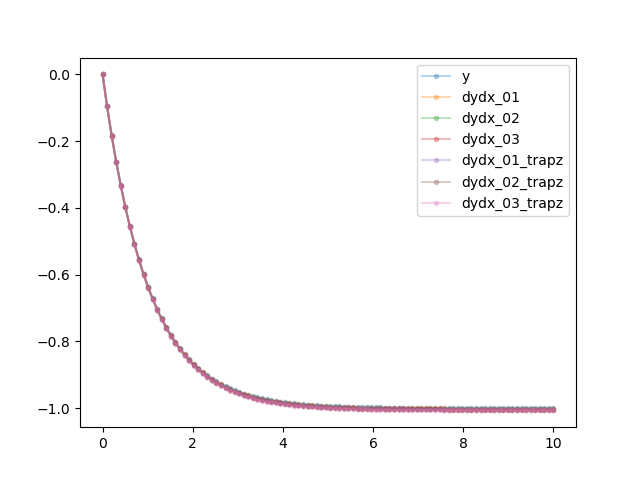

In [195]:
# assign a function:

x = np.linspace(0,10,100)
y = np.exp(-x)-1

dydx_01 = np.gradient(y,x,edge_order=2)
# for i in range(len(x)):
int_y_01 = [integrate.simpson(dydx_01[:i+1],x[:i+1]) for i in range(len(x))]
int_y_01_trapz = [integrate.trapz(dydx_01[:i+1],x[:i+1]) for i in range(len(x))]
dydx_02 = np.gradient(int_y_01, x,edge_order=2)
dydx_02_trapz = np.gradient(int_y_01_trapz, x,edge_order=2)
int_y_02 = [integrate.simpson(dydx_02[:i+1],x[:i+1]) for i in range(len(x))]
int_y_02_trapz = [integrate.trapz(dydx_02_trapz[:i+1],x[:i+1]) for i in range(len(x))]
dydx_03 = np.gradient(int_y_02, x,edge_order=2)
dydx_03_trapz = np.gradient(int_y_02_trapz, x,edge_order=2)
int_y_03 = [integrate.simpson(dydx_03[:i+1],x[:i+1]) for i in range(len(x))]
int_y_03_trapz = [integrate.trapz(dydx_03_trapz[:i+1],x[:i+1]) for i in range(len(x))]

fig,ax = plt.subplots()
ax.plot(x,y,'.-', alpha = 0.3, label='y')
ax.plot(x,int_y_01,'.-', alpha = 0.3, label="dydx_01")
ax.plot(x,int_y_02,'.-', alpha = 0.3, label="dydx_02")
ax.plot(x,int_y_03,'.-', alpha = 0.3, label="dydx_03")
ax.plot(x,int_y_01_trapz,'.-', alpha = 0.3, label="dydx_01_trapz")
ax.plot(x,int_y_02_trapz,'.-', alpha = 0.3, label="dydx_02_trapz")
ax.plot(x,int_y_03_trapz,'.-', alpha = 0.3, label="dydx_03_trapz")
ax.legend()
plt.show()

It does. Observe the tail of $y = e^{-x}$ and see how it changes as the function is repeatedly differentiated and integrated. Note that `integrate.simpson` is a fourth-order accurate scheme whilst the `np.gradient` function is a central difference scheme, and so is second-order accurate.

Try this without adding the extra flux tubes on either side. Thus, first create the adjusted_mass vector by slicing the original, excluding the first entry. The last entry coincides with psi_levels[-1], so don't need to exclude it.

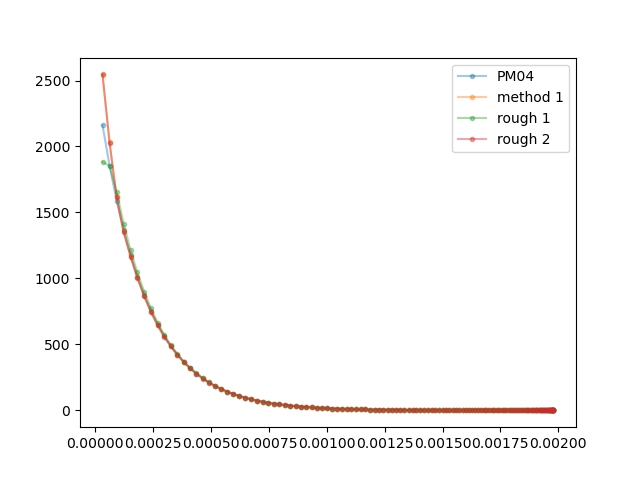

In [196]:
adjusted_mass_reduced = adjusted_mass[1:]

# Method 1: integrate dmdpsi and add adjusted mass, then differentiate
mass_psi_red = np.array([integrate.simpson(pm04_dmdpsi[:i+1], psi_levels[:i+1]) for i in range(len(psi_levels))])
mass_psi_adjust_red = mass_psi_red + adjusted_mass_reduced
dmdpsi_adj_red = np.gradient(mass_psi_adjust_red, psi_levels, edge_order=2)
# Rough 1
dmdpsi_rough_1_red = pm04_dmdpsi[:-1] + adjusted_mass_reduced[:-1]/(psi_levels[1:]-psi_levels[:-1])
# Rough 2
dmdpsi_rough_2_red = pm04_dmdpsi + np.gradient(adjusted_mass_reduced,psi_levels,edge_order=2)

fig,ax = plt.subplots()
ax.plot(psi_levels, pm04_dmdpsi, '.-', alpha = 0.4, label="PM04")
ax.plot(psi_levels, dmdpsi_adj_red, '.-', alpha = 0.4, label="method 1")
ax.plot(psi_levels[:-1],dmdpsi_rough_1_red, '.-', alpha = 0.4, label="rough 1")
ax.plot(psi_levels,dmdpsi_rough_2_red, '.-', alpha = 0.4, label="rough 2")
ax.legend()
plt.show()

Integrate these profiles and subtract away mass_psi, and see if remainder matches adjusted_mass_reduced:

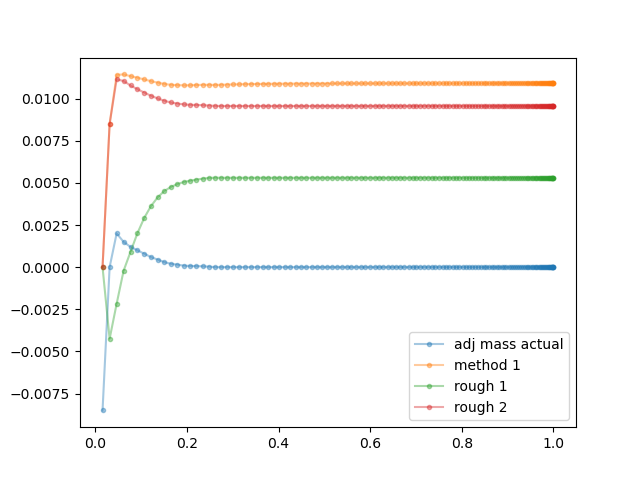

In [197]:
# integrate methods
mass_psi_method_1_red = np.array([integrate.simpson(dmdpsi_adj_red[:i+1],psi_levels[:i+1]) for i in range(len(psi_levels))])
mass_psi_rough_1_red = np.array([integrate.simpson(dmdpsi_rough_1_red[:i+1],psi_levels[:i+1]) for i in range(len(psi_levels)-1)])
mass_psi_rough_2_red = np.array([integrate.simpson(dmdpsi_rough_2_red[:i+1],psi_levels[:i+1]) for i in range(len(psi_levels))])

adj_mass_method_1_red = mass_psi_method_1_red - mass_psi_red
adj_mass_rough_1_red = mass_psi_rough_1_red - mass_psi_red[:-1]
adj_mass_rough_2_red = mass_psi_rough_2_red - mass_psi_red

fig,ax = plt.subplots()
ax.plot(psi_0/psi_star*psi_levels,adjusted_mass_reduced,'.-', alpha = 0.4,label="adj mass actual")
ax.plot(psi_0/psi_star*psi_levels,adj_mass_method_1_red,'.-', alpha = 0.4,label="method 1")
ax.plot(psi_0/psi_star*psi_levels[:-1],adj_mass_rough_1_red,'.-', alpha = 0.4,label="rough 1")
ax.plot(psi_0/psi_star*psi_levels,adj_mass_rough_2_red,'.-', alpha = 0.4,label="rough 2")
ax.legend()
plt.show()

Check how accurate rough 1 is by getting the cumulative mass $M(\psi)$, finding the mass between surfaces, then reconstructing $dM/d\psi$ by doing $\Delta M/\Delta \psi$

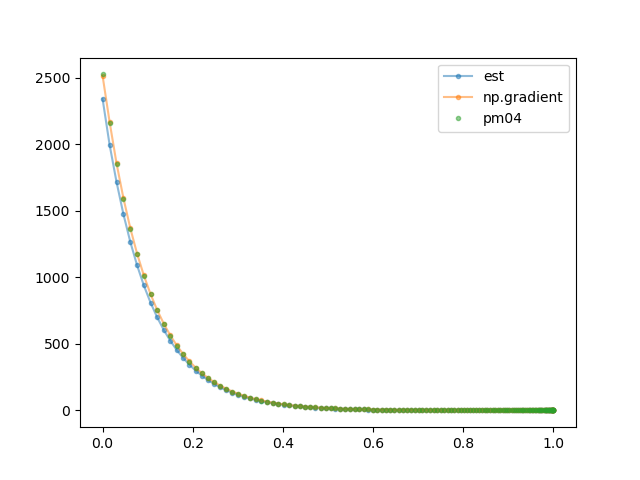

In [212]:
est_dmdpsi = (mass_psi[1:] - mass_psi[:-1])/(psi_levels_append[1:-1] - psi_levels_append[:-2])
est_dmdpsi_2 = np.gradient(mass_psi,psi_levels_append[:-1],edge_order=2)
fig,ax = plt.subplots()
ax.plot(psi_0/psi_star*psi_levels_append[:-2], est_dmdpsi,'.-', alpha = 0.5, label="est")
ax.plot(psi_0/psi_star*psi_levels_append[:-1], est_dmdpsi_2,'.-', alpha = 0.5, label="np.gradient")
ax.plot(psi_0/psi_star*psi_levels_append, pm04_dmdpsi_append,'.', alpha = 0.5, label="pm04")
# ax.plot(psi_levels_append[:-1],mass_psi,'.-')
ax.legend()
plt.show()

The reason the forward difference scheme is worse is because it calculates the gradient by connecting adjacent points $(x_i,x_{i+1})$ with a straight line and using rise-over-run. Whereas in reality the function at $x_i$ has a steeper gradient at the point, but "curves" down as it approaches $x_{i+1}$. Hence the instantaneous slope at $x_i$ is larger than the estimated gradient calculates. The centred difference scheme of `np.gradient` is better at accounting for this slope.

Now we test whether we can modify $dM/d\psi$ the rough 1 way, but instead of integrating, perform a finite sum, to see whether we can get back $M(\psi) + \Delta M_a$.

In [219]:
# print the total mass of the unmodified profile
print(f"M(psi_*) = {mass_psi[-1]} M_a")

# print total adjusted mass (should sum to zero)
print(f"Sum[M_a(psi)] = {np.sum(adjusted_mass)}")

# do a finite sum of pm04_dmdpsi_append to see if it adds to M(psi_star)
dpsi = psi_levels_append[1:] - psi_levels_append[:-1]
delta_m_i = pm04_dmdpsi_append[:-1] * dpsi
sum_delta_m = np.sum(delta_m_i)
print(f"Sum delta M = {sum_delta_m} M_a")

M(psi_*) = 0.5000020801477927 M_a
Sum[M_a(psi)] = -1.734723475976807e-18
Sum delta M = 0.5379034597303163 M_a


Why is it inaccurate? Show graphically by plotting $M(\psi)$ and $(\Delta M/\Delta\psi)\Delta \psi$

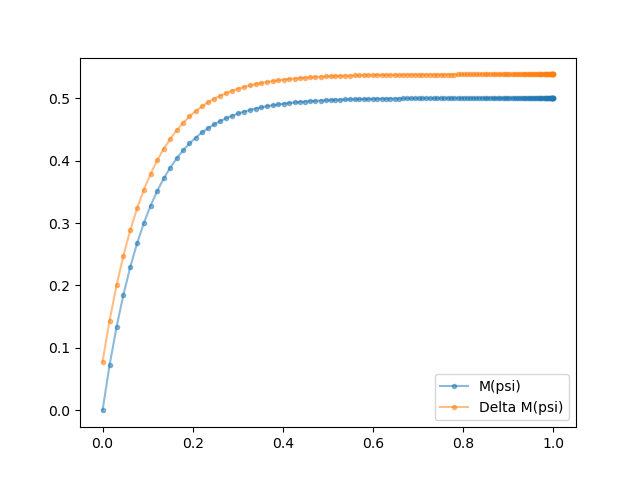

In [221]:
cumul_delta_m_i = np.cumsum(delta_m_i)

fig,ax = plt.subplots()
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, mass_psi,'.-', alpha=0.5,label="M(psi)")
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, cumul_delta_m_i,'.-', alpha=0.5,label="Delta M(psi)")
ax.legend()
plt.show()

It's by definition; $M(psi)$ is the mass contained between $0\leq\psi'\leq \psi$, so $M(0) \equiv 0$. Whilst the sum adds up the mass between $\psi_i\leq\psi'\leq \psi_{i+1}$, so there is a finite mass in the first fluxtube. We need to redefine the finite sum. 

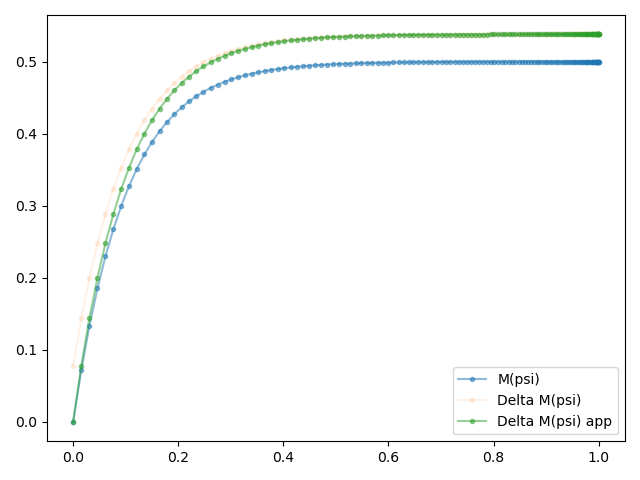

In [231]:
delta_m_i_append = np.append(0,delta_m_i)
cumul_delta_m_i_app = np.cumsum(delta_m_i_append)

fig,ax = plt.subplots()
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, mass_psi,'.-', alpha=0.5,label="M(psi)")
ax.plot(psi_levels_append[:-1]*psi_0/psi_star, cumul_delta_m_i,'.-', alpha=0.1,label="Delta M(psi)")
ax.plot(psi_levels_append*psi_0/psi_star, cumul_delta_m_i_app,'.-', alpha=0.5,label="Delta M(psi) app")
ax.legend()
plt.tight_layout()
plt.show()


The overestimation is because a simple sum of $dM/d\psi \, \Delta\psi$ will overestimate the integral. So the proper way **must** be to integrate.